In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker 
import pickle
import re, sys
import pymongo
import sncosmo
from scipy.stats.distributions import chi2
from astropy.table import Table


In [2]:
# Depending on whether the library was added or not, you might have to manually add the base dir to the python path
sys.path.append('/Users/jnordin/github/ampelFeb25')

In [3]:
# We try to load the main loader class for warped templates
from warpTemplate import WarpfitTemplateLoader, add_warpclasses

In [4]:
df_bts = pd.read_csv('/Users/jnordin/data/ztf/bts/bts_explorer_241122.csv')

In [5]:
df_bts = add_warpclasses(df_bts, purge=True)

In [6]:
# Which warp class to parse for?
# Category: (n)arrow, (e)xtended, (w)ide or (a)ll?
category = 'n'

In [7]:
classlist = list(set(df_bts['type_'+category]))

In [8]:
classlist

['SN Ia',
 'SLSN-II',
 'SN IIn',
 'SN II',
 'SN Ia-CSM',
 'SN Ia-pec',
 'SN Ic-BL',
 'SLSN-I',
 'SN Ia-SC',
 'SN Ia-91T',
 'SN Iax',
 'SN Ic',
 'SN IIP',
 'SN Ib/c',
 'SN IIb',
 'SN Ib',
 'SN Ibn',
 'SN Ia-91bg']

What happens here:
1. Pick a SN from BTS together with the base class you which to use to fit against
2. Retrieve SN information: redshift and photometry.
3. Decide on how many templates you wish to fit to and (randmoly reterieve these). Can become many!
4. Fit SN to each of the selected templates
5. Print/plot results for the best fit

### 1. Pick a SN from BTS together with the base class you which to use to fit against

In [9]:
#snname = 'ZTF20abbbumr'
#snname = 'ZTF19aailltc'

# Bad cases from suleyman
#snname = 'ZTF19aanijpu' # Ic
#template_class_id = 8   # Ok, but not amazing w/o itself
#template_class_id = 4   # The same ...

#snname = 'ZTF19abcegvm' # Ic
#template_class_id = 8   # Ok, but not amazing
#template_class_id = 4   # The same ...

#snname = 'ZTF18abfcmjw' # Ib
#template_class_id = 0   # Ok, but not amazing
#template_class_id = 4   # The same ...

#snname = 'ZTF19aalouag' # Ib
#template_class_id = 0   # Ok, but not amazing
#template_class_id = 4   # The same ...


snname = 'ZTF21aamobbh'
#template_class_id = 0   # Ok, but not amazing
template_class_id = 4   # The same ...

# Only use good fits?
min_fit_quality = 'bronze'
cutself = False # If set to False, it typically should fit perfectly

fit_class = 'SN Ib/c (e)'

In [10]:
print('Fitting to templates of class', fit_class)

Fitting to templates of class SN Ib/c (e)


### 2. Retrieve SN information: redshift and photometry.

In [11]:
sndict = df_bts.loc[df_bts['ZTFID']==snname,:].iloc[0]

In [12]:
print('looking at {} - type {}'.format(snname, sndict['type']))

looking at ZTF21aamobbh - type SN Ibn


In [13]:
client = pymongo.MongoClient()
db = client.bts_ipacfp_strictbase    # Only final lc. try bts_ipacfp_strictbase_full for all alerts

In [14]:
def get_db_table( name, database, tabulators ):
    """
    For ZTF name, get photopoints and then tables. 
    """
    from ampel.ztf.view.ZTFFPTabulator import ZTFFPTabulator
    from ampel.ztf.util.ZTFIdMapper import ZTFIdMapper

    # Name
    if isinstance(name, int):    
        # Assuming this is already a DB stock
        stock = int
    elif re.search('ZTF', name):
        stock = ZTFIdMapper.to_ampel_id(name)
    else:
        raise ValueError(f"Cannot parse {name}" )

    # Obtain photopoints
    dps = [dp for dp in database.t0.find({'stock':stock})]

    # Convert to table(s)
    ftables = [
        tabulator.get_flux_table(dps) for tabulator in tabulators
    ]
    if len(ftables)>1:
        raise NotImplementedError("Debug appending two tabulator tables.")
    return ftables.pop(0)
def get_ztftable_from_ampel(ztfid: str, dbhandle, include_sigma: float = 5., **kwarg) -> Table:
    """
    Given a ZTF name and a local AMPEL DB:
    - Retrieve available photometric data.
    - Reject outliers. 
    - Return an astropy table useful e.g. for sncosmo. 

    Parameters:
    - ztfid: str : ZTF name, e.g. ZTF18aaayemw
    - dbhandle: Database : AMPEL MongoDB handle
    - inclusion_sigma: float : Sigma threshold for outlier rejection.
    - kwarg: dict : Additional arguments added to table meta.

    tab = get_ztftable_from_ampel('ZTF22aaa', dbhandle, inclusion_sigma=5., z=0.03, type='SN Ia')

    """
    from ampel.ztf.view.ZTFFPTabulator import ZTFFPTabulator
    from ampel.ztf.util.ZTFIdMapper import ZTFIdMapper

    # Load photopoints from AMPEL DB
    tabulators = [
        ZTFFPTabulator(inclusion_sigma=include_sigma)
        ]
    tab = get_db_table(ztfid, database=dbhandle, tabulators=tabulators)
    tab.sort('time')

    tab.meta = {
            'object_id':ztfid,
            **kwarg
        }

    return tab

In [15]:
# Lets grab some data, starting with the target SN
# Warning: Note that the redshift and type also gets added to the meta information of the photometry table!
tab = get_ztftable_from_ampel( snname, db, 
                              redshift=float(sndict['redshift']), 
                              type = sndict['type'] )

In [16]:
tab

time,flux,fluxerr,band,zp,zpsys
float64,float64,float64,str4,int64,str2
2459267.7328819,210.9022351167764,19.267585744937822,ztfg,25,ab
2459267.7967477,172.48023770149467,17.27548936438502,ztfr,25,ab
2459269.7316898,572.3355529988397,23.85749695507501,ztfg,25,ab
2459269.7949884,471.4383877769693,22.166632408695445,ztfr,25,ab
2459271.7292361,666.230760859076,39.79961328401539,ztfg,25,ab
2459271.7558912,564.6038889919546,34.6945602870579,ztfr,25,ab
2459273.6715625,607.0140576182661,38.00211821338395,ztfg,25,ab
2459273.7327199,569.2819577187154,44.77500266302103,ztfr,25,ab
2459275.6891088,492.4073474232623,15.201148268562257,ztfg,25,ab


In [17]:
# Estimate significant detection
dps = sum( (np.abs(tab['flux']) / tab['fluxerr'])>5 )

In [18]:
dps

19

In [19]:
set(tab['band'])

{'ztfg', 'ztfr'}

### 3. Decide on how many templates you wish to fit to and (randmoly reterieve these).

In [20]:
# Parameters for fit template retrieval

if cutself:
    exclude_input = [snname] # Will reject any warptemplate containing any of these (either as sn or template basis)
else:
    exclude_input = []
# How to define templates?
# - How many templates per sn basis? 
#      * if 'all' it will return one copy of each template, 
#.     * if int it will return that many, drawn according to the template probability, 
#      * if -int it will return that many copies drawn from a uniform probabilitiy
#      Note: draws made with replacement, so multiple copies can be returned if int is larger than the available number of templates (often 3)
template_selection = 'all'
# - How many sn basis?
#.     * if 'all', take one of each
#.     * if an int, draw these randomly (with replacement)
#.     Note: how many templates are returned is decided by the above parameter.
snbasis_selection = 'all'



warpdir = '/Users/jnordin/data/models/sncosmo/warpmod'


In [21]:
warploader = WarpfitTemplateLoader(warpdir)

In [22]:
templates = warploader.get_templates(
    fitclass=fit_class,
    exclude_input = exclude_input, 
    template_selection=template_selection,
    snbasis_selection=snbasis_selection,
    min_fit_quality = min_fit_quality,
    random_seed=42
)

2026-06-22 14:07:09,781 [INFO] Using random seed: 42
2026-06-22 14:07:09,781 [INFO] Loading warpcoeffs from /Users/jnordin/data/models/sncosmo/warpmod/warpcoeffs_v3_SN Ibc (e).pkl
2026-06-22 14:07:09,785 [INFO] Filtering SN bases with min_fit_quality=bronze
2026-06-22 14:07:09,785 [INFO] SN basis ZTF18aanjzkp: 5 templates after quality filtering (5 original)
2026-06-22 14:07:09,786 [INFO] SN basis ZTF18abfzhct: 5 templates after quality filtering (5 original)
2026-06-22 14:07:09,786 [INFO] SN basis ZTF18acbzvpg: 5 templates after quality filtering (5 original)
2026-06-22 14:07:09,786 [INFO] SN basis ZTF18accaqrr: 5 templates after quality filtering (5 original)
2026-06-22 14:07:09,786 [INFO] SN basis ZTF19aapwnmb: 5 templates after quality filtering (5 original)
2026-06-22 14:07:09,786 [INFO] SN basis ZTF19aavkvpw: 5 templates after quality filtering (5 original)
2026-06-22 14:07:09,787 [INFO] SN basis ZTF19aavoweu: 5 templates after quality filtering (5 original)
2026-06-22 14:07:09,7

### 4. Fit SN to each of the selected templates

In [24]:
# Loop through templates, fit and plot the best...
bestmodel = None
for k, template in enumerate(templates):
    fitprop = ['t0', 'amplitude', 'hostebv']
    try:
        wresult, wfitted_model = sncosmo.fit_lc(
                        tab, template['model'],
                        fitprop,  # parameters of model to vary
                    )
    except RuntimeError:
        print(k,len(templates),template)
        print('fit failed')
        continue
    # Try to limit to models that use all the data
    if wresult['ndof']<(dps-len(fitprop)):
        print(k,len(templates),template)
        print('... datapoints rejected, skipping this for now.')
        continue
    # Check peak fit
    if (wresult['parameters'][1] < tab['time'].min()) or (wresult['parameters'][1] > tab['time'].max()):
        print(k,len(templates),template)
        print('...peak fit outside data time range. keeping since this could be a phase 0 one ...')
#        continue
    
    # Evaluate
    if wresult['success']:
        if bestmodel is None:
            bestmodel = [template,wfitted_model, wresult['chisq'] / wresult['ndof']]
        elif wresult['chisq'] / wresult['ndof'] < bestmodel[2]:
            bestmodel = [template,wfitted_model, wresult['chisq'] / wresult['ndof']]
#    sncosmo.plot_lc(tab, wfitted_model)

/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/iminuit/util.py:177: IMinuitWarning: Assigned errors must be positive. Non-positive values are replaced by a heuristic.
  warnings.warn(


4 507 {'basis_sn': 'ZTF18aanjzkp', 'model': <sncosmo.models.Model object at 0x1416574c0>, 'template_prob': 0.2000010565201934}
...peak fit outside data time range. keeping since this could be a phase 0 one ...
6 507 {'basis_sn': 'ZTF18abfzhct', 'model': <sncosmo.models.Model object at 0x141656920>, 'template_prob': 0.2004710491379025}
...peak fit outside data time range. keeping since this could be a phase 0 one ...
9 507 {'basis_sn': 'ZTF18abfzhct', 'model': <sncosmo.models.Model object at 0x141657c40>, 'template_prob': 0.19935510477679066}
...peak fit outside data time range. keeping since this could be a phase 0 one ...
14 507 {'basis_sn': 'ZTF18acbzvpg', 'model': <sncosmo.models.Model object at 0x1416747c0>, 'template_prob': 0.1999999687720491}
...peak fit outside data time range. keeping since this could be a phase 0 one ...
25 507 {'basis_sn': 'ZTF19aavkvpw', 'model': <sncosmo.models.Model object at 0x1416763e0>, 'template_prob': 0.20089445367167133}
...peak fit outside data time

/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/sncosmo/models.py:1997: RuntimeWarning: overflow encountered in power
  return extinction.apply(extinction.ccm89(wave, ebv * r_v, r_v), flux)
/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/sncosmo/models.py:1997: RuntimeWarning: invalid value encountered in multiply
  return extinction.apply(extinction.ccm89(wave, ebv * r_v, r_v), flux)


58 507 {'basis_sn': 'ZTF19abdoior', 'model': <sncosmo.models.Model object at 0x14169c9a0>, 'template_prob': 0.19551651171605164}
...peak fit outside data time range. keeping since this could be a phase 0 one ...
64 507 {'basis_sn': 'ZTF19abfsxpw', 'model': <sncosmo.models.Model object at 0x14169d8d0>, 'template_prob': 0.20270321523974438}
...peak fit outside data time range. keeping since this could be a phase 0 one ...
72 507 {'basis_sn': 'ZTF19ablesob', 'model': <sncosmo.models.Model object at 0x14169eb60>, 'template_prob': 0.18180531594425803}
...peak fit outside data time range. keeping since this could be a phase 0 one ...
73 507 {'basis_sn': 'ZTF19ablesob', 'model': <sncosmo.models.Model object at 0x14169eda0>, 'template_prob': 0.18180531325983615}
...peak fit outside data time range. keeping since this could be a phase 0 one ...
84 507 {'basis_sn': 'ZTF19abqykei', 'model': <sncosmo.models.Model object at 0x1416aca90>, 'template_prob': 0.33333575803884063}
...peak fit outside dat

/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/sncosmo/models.py:119: RuntimeWarning: overflow encountered in multiply
  return np.sum(wave * trans * f, axis=1) * dwave / HC_ERG_AA
/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/sncosmo/models.py:1997: RuntimeWarning: overflow encountered in multiply
  return extinction.apply(extinction.ccm89(wave, ebv * r_v, r_v), flux)


394 507 {'basis_sn': 'ZTF21aartgiv', 'model': <sncosmo.models.Model object at 0x142a43bb0>, 'template_prob': 0.2004987845838297}
fit failed
397 507 {'basis_sn': 'ZTF21aawlcwh', 'model': <sncosmo.models.Model object at 0x142a08100>, 'template_prob': 0.20141798222438417}
...peak fit outside data time range. keeping since this could be a phase 0 one ...
405 507 {'basis_sn': 'ZTF21aaxxihx', 'model': <sncosmo.models.Model object at 0x142a08e80>, 'template_prob': 0.20000002299437603}
...peak fit outside data time range. keeping since this could be a phase 0 one ...
406 507 {'basis_sn': 'ZTF21aaxxihx', 'model': <sncosmo.models.Model object at 0x142a09030>, 'template_prob': 0.20000002296768632}
...peak fit outside data time range. keeping since this could be a phase 0 one ...
410 507 {'basis_sn': 'ZTF21aaygqkb', 'model': <sncosmo.models.Model object at 0x142a096f0>, 'template_prob': 0.07721812890852593}
...peak fit outside data time range. keeping since this could be a phase 0 one ...
413 507 

### 5. Print/plot results for the best fit

In [25]:
if (wresult['parameters'][1] < tab['time'].min()) or (wresult['parameters'][1] > tab['time'].max()):
    print('peak fit outside data time range')

In [26]:
bestmodel[0]

{'basis_sn': 'ZTF20abaszgh',
 'model': <sncosmo.models.Model at 0x141c69690>,
 'template_prob': 0.18091596398928583}

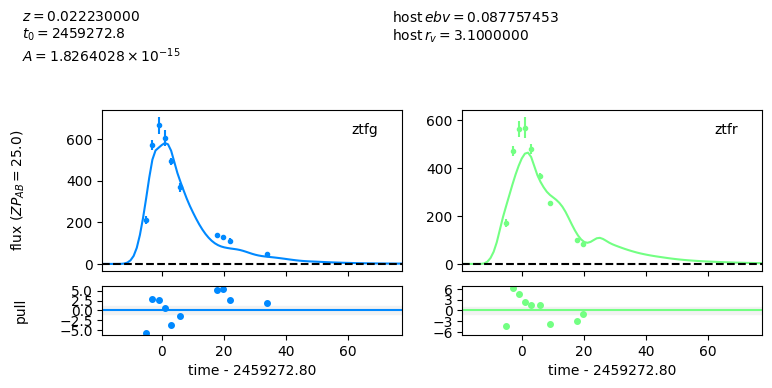

In [27]:
_ = sncosmo.plot_lc(tab, bestmodel[1])

In [28]:
sns = [temp["basis_sn"] for temp in templates]

In [29]:
snname in set(sns)

False